<a href="https://colab.research.google.com/github/hbisgin/DeepLearning/blob/main/DL_17_LearningRate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/EdwardRaff/Inside-Deep-Learning/refs/heads/main/idlmam.py

--2026-04-05 15:06:13--  https://raw.githubusercontent.com/EdwardRaff/Inside-Deep-Learning/refs/heads/main/idlmam.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22064 (22K) [text/plain]
Saving to: ‘idlmam.py.2’

idlmam.py.2         100%[===================>]  21.55K  --.-KB/s    in 0.001s  

2026-04-05 15:06:13 (20.1 MB/s) - ‘idlmam.py.2’ saved [22064/22064]



In [5]:
%pip install torch torchvision tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
sys.path.append('/content/idlmam.py')

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

from tqdm.autonotebook import tqdm

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

import pandas as pd

from sklearn.metrics import accuracy_score

import time

from idlmam import train_simple_network, Flatten, weight_reset, set_seed, run_epoch

/tmp/ipykernel_166458/1084216111.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
/home/jj/PycharmProjects/DSC428/idlmam.py:215: SyntaxWarning: invalid escape sequence '\e'
  """Train simple neural networks


In [8]:
torch.backends.cudnn.deterministic=True
set_seed(45)

In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [10]:
def train_network(model, loss_func, train_loader, val_loader=None, test_loader=None,score_funcs=None,
                         epochs=50, device="cpu", checkpoint_file=None,
                         lr_schedule=None, optimizer=None, disable_tqdm=False
                        ):
    """Train simple neural networks

    Keyword arguments:
    model -- the PyTorch model / "Module" to train
    loss_func -- the loss function that takes in batch in two arguments, the model outputs and the labels, and returns a score
    train_loader -- PyTorch DataLoader object that returns tuples of (input, label) pairs.
    val_loader -- Optional PyTorch DataLoader to evaluate on after every epoch
    test_loader -- Optional PyTorch DataLoader to evaluate on after every epoch
    score_funcs -- A dictionary of scoring functions to use to evalue the performance of the model
    epochs -- the number of training epochs to perform
    device -- the compute lodation to perform training
    lr_schedule -- the learning rate schedule used to alter \eta as the model trains. If this is not None than the user must also provide the optimizer to use.
    optimizer -- the method used to alter the gradients for learning.

    """
    if score_funcs == None:
        score_funcs = {}#Empty set

    to_track = ["epoch", "total time", "train loss"]
    if val_loader is not None:
        to_track.append("val loss")
    if test_loader is not None:
        to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if val_loader is not None:
            to_track.append("val " + eval_score )
        if test_loader is not None:
            to_track.append("test "+ eval_score )

    total_train_time = 0 #How long have we spent in the training loop?
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []

    if optimizer == None:
        #The AdamW optimizer is a good default optimizer
        optimizer = torch.optim.AdamW(model.parameters())

    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device)
    for epoch in tqdm(range(epochs), desc="Epoch", disable=disable_tqdm):
        model = model.train()#Put our model in training mode

        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, prefix="train", desc="Training")

        results["epoch"].append( epoch )
        results["total time"].append( total_train_time )


        if val_loader is not None:
            model = model.eval() #Set the model to "evaluation" mode, b/c we don't want to make any updates!
            with torch.no_grad():
                run_epoch(model, optimizer, val_loader, loss_func, device, results, score_funcs, prefix="val", desc="Validating")

        #In PyTorch, the convention is to update the learning rate after every epoch
        if lr_schedule is not None:
            if isinstance(lr_schedule, torch.optim.lr_scheduler.ReduceLROnPlateau):
                lr_schedule.step(results["val loss"][-1])
            else:
                lr_schedule.step()

        if test_loader is not None:
            model = model.eval() #Set the model to "evaluation" mode, b/c we don't want to make any updates!
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")

        if checkpoint_file is not None:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'results' : results
                }, checkpoint_file)

    return pd.DataFrame.from_dict(results)

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_166458/2698981636.py:5: SyntaxWarning: invalid escape sequence '\e'
  """Train simple neural networks


In [11]:
epochs = 50 #50 epochs of training
B = 256 # a respectable average batch size
train_data = torchvision.datasets.FashionMNIST("./data", train=True, transform=transforms.ToTensor(), download=True)
test_data = torchvision.datasets.FashionMNIST("./data", train=False, transform=transforms.ToTensor(), download=True)

train_loader = DataLoader(train_data, batch_size=B, shuffle=True)
test_loader = DataLoader(test_data, batch_size=B)

100.0%
100.0%
100.0%
100.0%


In [12]:
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 28*28 #28 * 28 images
#Hidden layer size
n = 128
#How many channels are in the input?
C = 1
#How many classes are there?
classes = 10

fc_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n),
    nn.Tanh(),
    nn.Linear(n,  n),
    nn.Tanh(),
    nn.Linear(n,  n),
    nn.Tanh(),
    nn.Linear(n, classes),
)

In [13]:
eta_0 = 0.1

In [14]:
loss_func = nn.CrossEntropyLoss()
#Using our new tran_network function in a maner equivalent to what we might have done previously
fc_results = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=torch.optim.SGD(fc_model.parameters(), lr=eta_0), score_funcs={'Accuracy': accuracy_score}, device=device)

Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 21.20it/s]
                                                                                
Epoch:   2%|▋                                    | 1/50 [00:12<10:10, 12.46s/it]


Training:  99%|██████████████████████████████▋| 233/235 [00:10<00:00, 23.61it/s]
                                                                                
Training:   1%|▍                                | 3/235 [00:00<00:10, 23.10it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 22.59it/s]
                                                                                
Training:   4%|█▎                               | 9/235 [00:00<00:09, 23.82it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 22.04it/s]
                                                                                
Training:   6%|██                              | 15/235 [00:00<00:09, 24.43it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 24.47it/s]
                                                                                
Training:   9%|██▊                             | 21/235 [00:00<00:09, 23.74it/s]


...

Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 23.21it/s]
                                                                                
Testing:  52%|█████████████████▊                | 21/40 [00:00<00:00, 24.58it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 23.74it/s]
                                                                                
Testing:  68%|██████████████████████▉           | 27/40 [00:01<00:00, 25.21it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 17.29it/s]
                                                                                
Testing:  82%|████████████████████████████      | 33/40 [00:01<00:00, 26.27it/s]


Training:  99%|██████████████████████████████▋| 233/235 [00:09<00:00, 23.71it/s]
                                                                                
Testing:  98%|█████████████████████████████████▏| 39/40 [00:01<00:00, 25.39it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 21.32it/s]
                                                                                
Epoch: 100%|████████████████████████████████████| 50/50 [09:47<00:00, 11.76s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

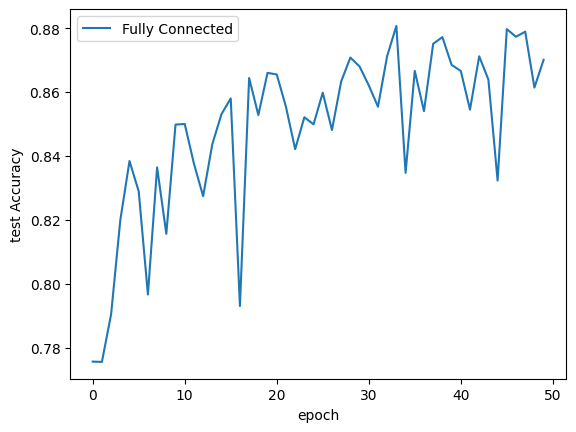

In [15]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Connected')

Let's illustrate fixed and decaying learning rates

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_166458/2261706120.py:9: SyntaxWarning: invalid escape sequence '\e'
  sns.lineplot(x=epochs_input, y=eta_init, color='red', label="$\eta_0$")
/tmp/ipykernel_166458/2261706120.py:10: SyntaxWarning: invalid escape sequence '\e'
  ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label="$\eta_0 \cdot \gamma^t$")


Text(0, 0.5, 'Learning Rate')

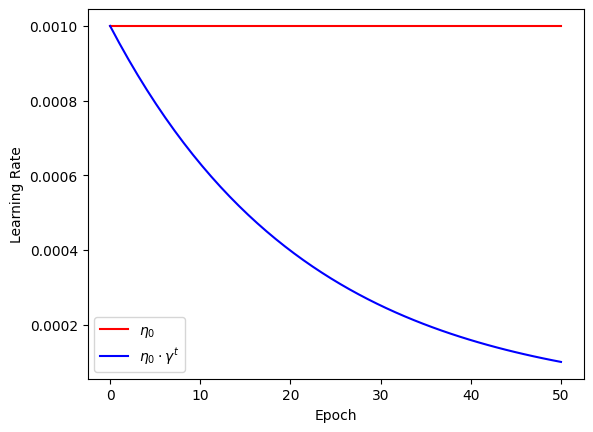

In [16]:
T=50 #total epochs
epochs_input = np.linspace(0, 50, num=50) #generating all of the different t values
eta_init = 0.001 #pretend initial learning rate $\eta_0$
eta_min = 0.0001 #pretend desired minimum learning rate $\eta_{\mathit{min}}$
gamma = np.power(eta_min/eta_init,1./T) #Compute the decay rate $\gamma$

effective_learning_rate = eta_init*np.power(gamma, epochs_input) #all of the $\eta_t$ values

sns.lineplot(x=epochs_input, y=eta_init, color='red', label="$\eta_0$")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label="$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')


Reset weights and train again

In [17]:
fc_model.apply(weight_reset)#re-randomize the weights of our model so that we don't need to define it again

eta_min = 0.0001 #Our desired final learning rate $\eta_{\mathit{min}}$

gamma_expo = (eta_min/eta_0)**(1/epochs)#compute $\gamma$ that results in $\eta_{\mathit{min}}$

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0) #Set up the optimizer
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma_expo)#pick a schedule and pass the optimizer in
#train like normal and pass along the desired optimizer and schedule
fc_results_expolr = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, lr_schedule=scheduler, score_funcs={'Accuracy': accuracy_score}, device=device)

Training: 100%|███████████████████████████████| 235/235 [00:10<00:00, 23.37it/s]
                                                                                
Epoch:   2%|▋                                    | 1/50 [00:12<10:09, 12.43s/it]


Training:  99%|██████████████████████████████▋| 233/235 [00:09<00:00, 24.73it/s]
                                                                                
Training:   1%|▍                                | 3/235 [00:00<00:09, 25.04it/s]


Training: 100%|███████████████████████████████| 235/235 [00:10<00:00, 25.39it/s]
                                                                                
Training:   3%|▊                                | 6/235 [00:00<00:09, 23.04it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 24.16it/s]
                                                                                
Training:   4%|█▎                               | 9/235 [00:00<00:10, 20.96it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 21.52it/s]
                                                                                
Training:   6%|██                              | 15/235 [00:00<00:09, 24.03it/s]


...

Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 23.13it/s]
                                                                                
Testing:  15%|█████▎                             | 6/40 [00:00<00:01, 26.27it/s]


Training:  99%|██████████████████████████████▋| 233/235 [00:10<00:00, 21.17it/s]
                                                                                
Testing:  30%|██████████▏                       | 12/40 [00:00<00:01, 23.08it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 23.27it/s]
                                                                                
Testing:  45%|███████████████▎                  | 18/40 [00:00<00:00, 25.77it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 22.56it/s]
                                                                                
Testing:  60%|████████████████████▍             | 24/40 [00:01<00:00, 23.77it/s]


Epoch: 100%|████████████████████████████████████| 50/50 [09:58<00:00, 11.97s/it]


<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_166458/1749357289.py:1: SyntaxWarning: invalid escape sequence '\e'
  sns.lineplot(x=epochs_input, y=eta_init, color='red', label="$\eta_0$")
/tmp/ipykernel_166458/1749357289.py:3: SyntaxWarning: invalid escape sequence '\e'
  ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label="$\eta_0 \cdot \gamma^t$")


Text(0, 0.5, 'Learning Rate')

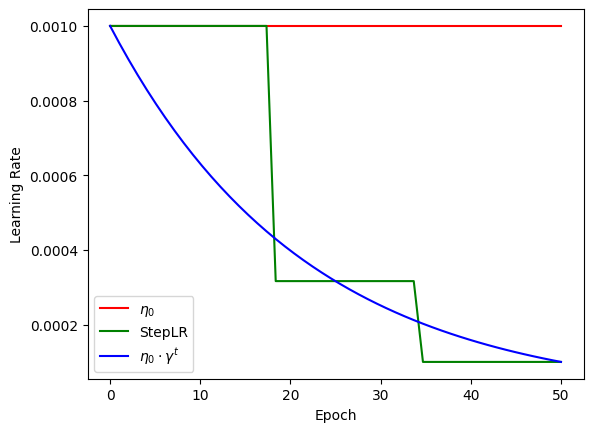

In [18]:
sns.lineplot(x=epochs_input, y=eta_init, color='red', label="$\eta_0$")
sns.lineplot(x=epochs_input, y=[eta_init]*18+[eta_init/3.16]*16+[eta_init/10]*16, color='green', label="StepLR")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label="$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')

In [19]:
fc_model.apply(weight_reset)

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, epochs//4, gamma=0.3)#I'm telling it to step down by a factor of $\gamma$ every epochs/4, so this will happen 4 times total.

fc_results_steplr = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, lr_schedule=scheduler, score_funcs={'Accuracy': accuracy_score}, device=device)


Training:  99%|██████████████████████████████▋| 233/235 [00:10<00:00, 21.84it/s]
                                                                                
Training:   0%|                                         | 0/235 [00:00<?, ?it/s]


Training:  99%|██████████████████████████████▋| 233/235 [00:09<00:00, 23.44it/s]
                                                                                
Training:   3%|▊                                | 6/235 [00:00<00:09, 23.67it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 23.97it/s]
                                                                                
Training:   5%|█▋                              | 12/235 [00:00<00:09, 24.45it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 24.47it/s]
                                                                                
Training:   8%|██▍                             | 18/235 [00:00<00:09, 22.93it/s]


Training: 100%|███████████████████████████████| 235/235 [00:10<00:00, 22.73it/s]
                                                                                
Training:   8%|██▍                             | 18/235 [00:00<00:09, 23.37it/s]


...

Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 23.24it/s]
                                                                                
Training:  86%|██████████████████████████▌    | 201/235 [00:08<00:01, 23.44it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 23.01it/s]
                                                                                
Training:  88%|███████████████████████████▎   | 207/235 [00:08<00:01, 24.99it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 23.61it/s]
                                                                                
Training:  91%|████████████████████████████   | 213/235 [00:09<00:00, 23.36it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:10<00:00, 24.53it/s]
                                                                                
Training:  93%|████████████████████████████▉  | 219/235 [00:09<00:00, 24.66it/s]


Training: 100%|██████████████████████████████▊| 234/235 [00:09<00:00, 22.97it/s]
                                                                                
Epoch: 100%|████████████████████████████████████| 50/50 [10:01<00:00, 12.03s/it]


Cosine annealing

<Axes: xlabel='epoch', ylabel='test Accuracy'>

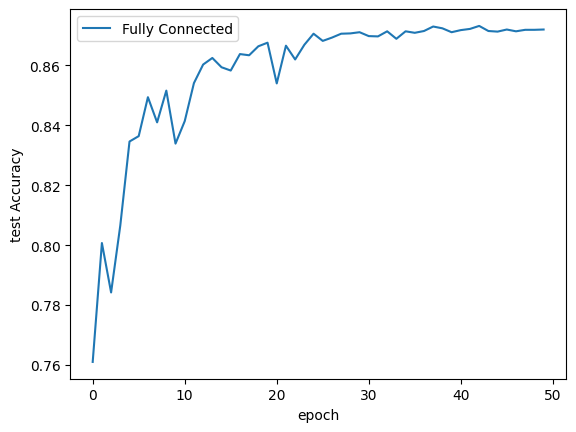

In [20]:

sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_steplr, label='Fully Connected')


Can you plot training and test accuracies to see how each learning rate is behaving?